RANDOM FOREST REGRESSION

In [1]:
# Local environment setup
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from pathlib import Path

DATASET_PATH = Path("household_power_consumption.txt")
if not DATASET_PATH.exists() and (Path("FRANCE_DATASET") / "household_power_consumption.txt").exists():
    DATASET_PATH = Path("FRANCE_DATASET") / "household_power_consumption.txt"

file_path = DATASET_PATH

df = pd.read_csv(
    file_path,
    sep=';',
    header=None
)

print("Original dataset shape:", df.shape)

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_25908\1616290886.py:9: DtypeWarning: Columns (0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Original dataset shape: (2075260, 9)


,0,1,2,3,4,5,6,7,8
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [4]:
df.columns = [
    'Date',
    'Time',
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [5]:
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

df = df.dropna()

df = df.sort_values('Datetime')
df = df.reset_index(drop=True)

print("Rows after cleaning:", len(df))

Rows after cleaning: 2049280


In [6]:
df = df.iloc[:20000].copy()

print("Records used:", len(df))

Records used: 20000


In [7]:
energy = df[['Global_active_power']].values

print("Energy data shape:", energy.shape)
print(energy[:10])

Energy data shape: (20000, 1)
[[4.216]
 [5.36 ]
 [5.374]
 [5.388]
 [3.666]
 [3.52 ]
 [3.702]
 [3.7  ]
 [3.668]
 [3.662]]


In [8]:
scaler = MinMaxScaler()

energy_scaled = scaler.fit_transform(energy)

print(energy_scaled[:10])

[[0.44998881]
 [0.57798165]
 [0.579548  ]
 [0.58111434]
 [0.38845379]
 [0.37211904]
 [0.39248154]
 [0.39225778]
 [0.38867756]
 [0.38800627]]


In [9]:
time_steps = 30

X = []
y = []

for i in range(time_steps, len(energy_scaled)):
    X.append(energy_scaled[i-time_steps:i, 0])
    y.append(energy_scaled[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19970, 30)
y shape: (19970,)


In [10]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15976, 30)
Testing data: (3994, 30)


In [11]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [12]:
print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Training Random Forest...


Random Forest training completed!


In [13]:
predictions = rf_model.predict(X_test)

print("Prediction completed!")
print("Number of predictions:", len(predictions))

Prediction completed!
Number of predictions: 3994


In [14]:
predictions_actual = scaler.inverse_transform(
    predictions.reshape(-1, 1)
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Actual values:")
print(y_test_actual[:5].flatten())

print("\nPredicted values:")
print(predictions_actual[:5].flatten())

Actual values:
[2.568 2.566 2.546 2.542 2.95 ]

Predicted values:
[2.54297628 2.55118632 2.62096396 2.55298379 2.45330553]


In [15]:
mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

print("MAE:", mae)

MAE: 0.1667741265352725


In [16]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

print("RMSE:", rmse)

RMSE: 0.379621983848629


In [17]:
r2 = r2_score(
    y_test_actual,
    predictions_actual
)

print("R² Score:", r2)

R² Score: 0.9353781713606086


In [18]:
print("======================================")
print("   RANDOM FOREST PERFORMANCE")
print("======================================")

print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

   RANDOM FOREST PERFORMANCE
MAE  : 0.1667741265352725
RMSE : 0.379621983848629
R²   : 0.9353781713606086


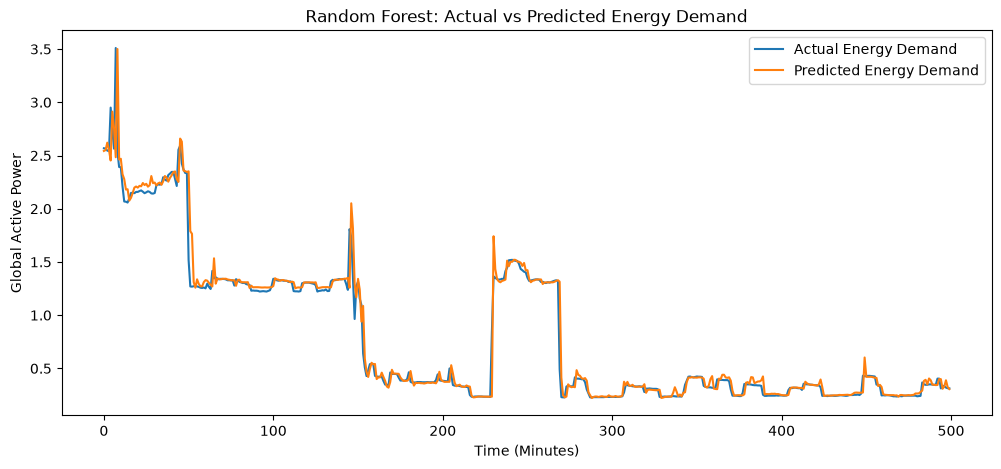

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual[:500],
    label='Actual Energy Demand'
)

plt.plot(
    predictions_actual[:500],
    label='Predicted Energy Demand'
)

plt.xlabel('Time (Minutes)')
plt.ylabel('Global Active Power')

plt.title('Random Forest: Actual vs Predicted Energy Demand')

plt.legend()

plt.show()

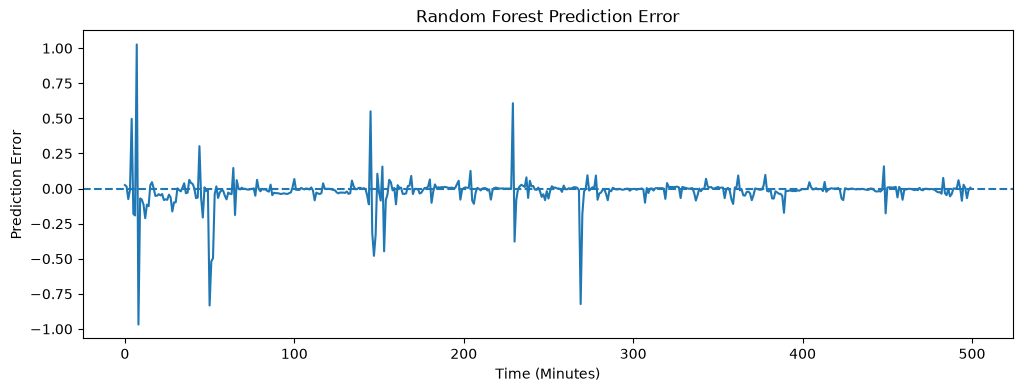

In [20]:
errors = (
    y_test_actual.flatten()
    - predictions_actual.flatten()
)

plt.figure(figsize=(12, 4))

plt.plot(errors[:500])

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Time (Minutes)')
plt.ylabel('Prediction Error')

plt.title('Random Forest Prediction Error')

plt.show()

In [21]:
results = pd.DataFrame({
    'Actual_Energy_Demand': y_test_actual.flatten(),
    'Predicted_Energy_Demand': predictions_actual.flatten()
})

results.head(10)

,Actual_Energy_Demand,Predicted_Energy_Demand
0,2.568,2.542976
1,2.566,2.551186
2,2.546,2.620964
3,2.542,2.552984
4,2.950,2.453306
5,2.732,2.912405
6,2.564,2.755814
7,3.510,2.483711
8,2.532,3.500315
9,2.392,2.462032


In [22]:
from pathlib import Path

OUTPUT_DIR = Path("RFR_Outputs")
if not OUTPUT_DIR.exists() and (Path("FRANCE_DATASET") / "RFR_Outputs").exists():
    OUTPUT_DIR = Path("FRANCE_DATASET") / "RFR_Outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREDICTION_PATH = OUTPUT_DIR / "random_forest_predictions.csv"

results.to_csv(
    PREDICTION_PATH,
    index=False
)

print(f"Predictions saved successfully to {PREDICTION_PATH}!")

Predictions saved successfully to RFR_Outputs\random_forest_predictions.csv!


In [23]:
import joblib

MODEL_PATH = OUTPUT_DIR / "random_forest_model.pkl"

joblib.dump(
    rf_model,
    MODEL_PATH
)

print(f"Random Forest model saved successfully to {MODEL_PATH}!")

Random Forest model saved successfully to RFR_Outputs\random_forest_model.pkl!


In [24]:
print("======================================")
print(" SMART GRID ENERGY DEMAND FORECASTING")
print("        RANDOM FOREST MODEL")
print("======================================")

print("Dataset Size     :", len(df))
print("Time Steps       :", time_steps)
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("--------------------------------------")
print("MAE              :", mae)
print("RMSE             :", rmse)
print("R² Score         :", r2)
print("--------------------------------------")
print("Trees            : 50")
print("Maximum Depth    : 15")
print("======================================")

 SMART GRID ENERGY DEMAND FORECASTING
        RANDOM FOREST MODEL
Dataset Size     : 20000
Time Steps       : 30
Training Samples : 15976
Testing Samples  : 3994
--------------------------------------
MAE              : 0.1667741265352725
RMSE             : 0.379621983848629
R² Score         : 0.9353781713606086
--------------------------------------
Trees            : 50
Maximum Depth    : 15
